# SmartStocks — Notebook 1: Data Ingestion & Cleaning

**Goal:** Fetch a ~150-stock universe (grouped below for downloads), understand what the raw data looks like, handle missing values and corporate actions, and sanity-check a few price series visually. **`sector_map.parquet` uses each ticker’s Yahoo Finance `info["sector"]` label** so downstream features and the frontend match `GET /stock/{ticker}` (dashboard sector filters).

**By the end of this notebook you should be able to answer:**
- What does a raw yfinance OHLCV DataFrame look like?
- Which stocks have missing data, and why?
- What is adjusted close and why does it matter?
- Is the cleaned data plausible? (The plot check)
- How do we persist this so we don't re-fetch every time?

---
## 0. Imports & config

In [ ]:
# TODO: import yfinance, pandas, numpy, matplotlib
from pathlib import Path
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO: set matplotlib style
plt.style.use("seaborn-v0_8")

# TODO: define DATA_DIR — always backend/data (works whether cwd is repo root, backend/, or backend/notebooks/)
_cwd = Path.cwd()
if _cwd.name == "notebooks":
    DATA_DIR = (_cwd.parent / "data").resolve()
elif _cwd.name == "backend":
    DATA_DIR = (_cwd / "data").resolve()
else:
    DATA_DIR = (_cwd / "backend" / "data").resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)

# TODO: set a LOOKBACK constant (e.g. '2y')
# how far back to pull stock history
LOOKBACK = "2y"



---
## 1. Define the stock universe


In [ ]:
# Keys use Yahoo Finance / yfinance sector vocabulary (matches GET /stock/{ticker}).
SECTORS = {
    'Technology': ['AAPL', 'MSFT', "NVDA", "AVGO", "AMD", "META", "ORCL", "PLTR", "IBM", "QCOM", "CRM", "UBER", "PANW", "SHOP", "DELL"],
    'Healthcare': ['LLY', "JNJ", "ABBV", "UNH", "MRK", "AMGN", "TMO", "PFE", "MDT", "HCA", "CI", "COR", "GSK", "NVO", "FMS"],
    'Financial Services': ["JPM", "BRK-B", "MA", "GS", "BAC", "MS", "SOFI", "WBS", "EWBC", "AFG", "ALLY", "V", "C", "RY", "WFC", "COF"],
    'Consumer Cyclical': ["AMZN", "TSLA", "HD", "SBUX", "NKE", "DIS", "ULTA", "LULU", "ABNB", "DASH", "GM", "EBAY", "F", "WSM", "CHWY"],
    'Consumer Defensive': ["WMT", "COST", "KO", "PG", "PEP", "UL", "CELH", "PM", "TGT", "HRL", "MDLZ", "GIS", "CAG", "KHC", "MO"],
    'Energy': ["XOM", "CVX", "COP", "WMB", "SLB", "EPD", "EOG", "MPC", "VLO", "PSX", "DVN", "DKL", "ARLP", "BSM", "OXY"],
    'Industrials': ["ETN", "LMT", "UPS", "DE", "HON", "MMM", "BA", "PCAR", "GE", "UNP", "CR", "AXON", "CAT", "FDX", "RTX"],
    'Basic Materials': ["LIN", "NEM", "SCCO", "FCX", "SHW", "AEM", "APD", "ALB", "LYB", "CENX", "EMN", "MOS", "CE", "PPG", "NUE"],
    'Utilities': ["PCG", "EIX", "NGG", "DTE", "ES", "POR", "MGEE", "NEE", "CEG", "SO", "AEP", "EXC", "IDA", "AVA", "WEC"],
    'Real Estate': ["WELL", "PLD", "EQIX", "AMT", "SPG", "DLR", "O", "PSA", "FRT", "BRX", "ADC", "BXP", "CUBE", "CTRE"],
}

# TODO: flatten to a single list
ALL_TICKERS = []
for sector_list in SECTORS.values(): 
    ALL_TICKERS.extend(sector_list)

# TODO: print count — should be ~150
print(f'Universe size: {len(ALL_TICKERS)}')

Universe size: 150


---
## 2. Fetch raw OHLCV data

**What yfinance returns:** A MultiIndex DataFrame — (Date, Ticker) or columns per ticker depending on how you call it. Spend time here just *looking* at the shape before doing anything to it.

In [ ]:
# TODO: call yf.download() for ALL_TICKERS with your LOOKBACK period
raw_df = yf.download(ALL_TICKERS, period=LOOKBACK, auto_adjust=True)

[*********************100%***********************]  150 of 150 completed


In [ ]:
print(raw_df.shape)
print(raw_df.head())

# TODO: print raw_df.columns (inspect the MultiIndex structure)
print(raw_df.columns)

# TODO: print raw_df.dtypes
print(raw_df.dtypes)

# QUESTION TO ANSWER: How many rows did you expect vs how many did you get?
# I expected 150 tickers * 2 years = 504 trading days, but i got 501. 

(501, 750)
Price            Close                                                \
Ticker            AAPL        ABBV        ABNB        ADC        AEM   
Date                                                                   
2024-05-07  180.754974  151.903259  159.809998  54.391838  63.932762   
2024-05-08  181.091919  149.940781  157.899994  53.610867  64.320946   
2024-05-09  182.905411  149.894043  147.050003  54.658283  66.087151   
2024-05-10  181.645187  150.221130  146.320007  55.264687  66.378288   
2024-05-13  184.850372  150.716400  149.130005  55.191177  65.747498   

Price                                                                 ...  \
Ticker            AEP         AFG         ALB       ALLY         AMD  ...   
Date                                                                  ...   
2024-05-07  83.742935  114.563042  126.996254  37.045750  154.429993  ...   
2024-05-08  84.404533  115.804634  125.943985  37.120968  153.619995  ...   
2024-05-09  85.580742  116.

### explanation of the structure of the data: 
(501 rows, 750 cols) = 501 trading days × 5 price types × 150 tickers

---
## 3. Inspect missing data

**Why stocks have missing data:**
- Market holidays (expected, fine)
- Stock was listed after your lookback start date (new IPO)
- Stock was delisted or renamed mid-period
- yfinance simply failed to fetch it

In [ ]:

print(raw_df.isna().sum().sum()  )       # total NaN count
print(raw_df.isna().any().any()  )        # True if any NaN anywhere

0
False


---
## 4. Handle corporate actions — Adjusted Close vs Close


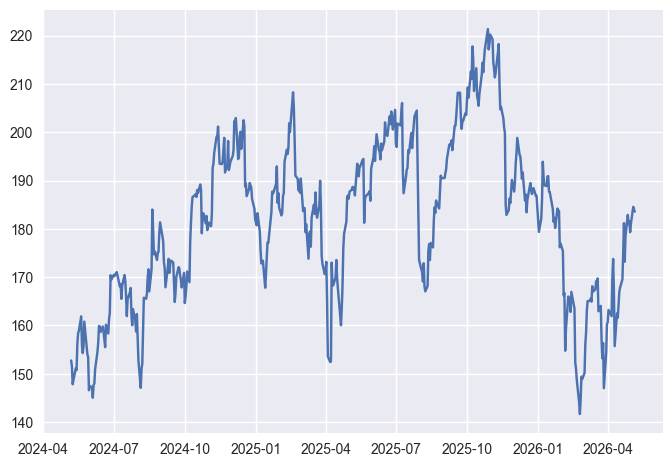

In [ ]:
# Plotting PANW stock after split
plt.plot(raw_df["Close"]["PANW"]) 

---
## 6. Sanity check — plot a few price series

**This is not optional.** Before saving anything, look at the data. Plot one stock from each sector. You're checking:
- Does the price history look continuous and plausible?
- Are there any obvious spikes or drops that look like data errors?
- Do the magnitudes make sense? (A $5 stock shouldn't suddenly show $500)


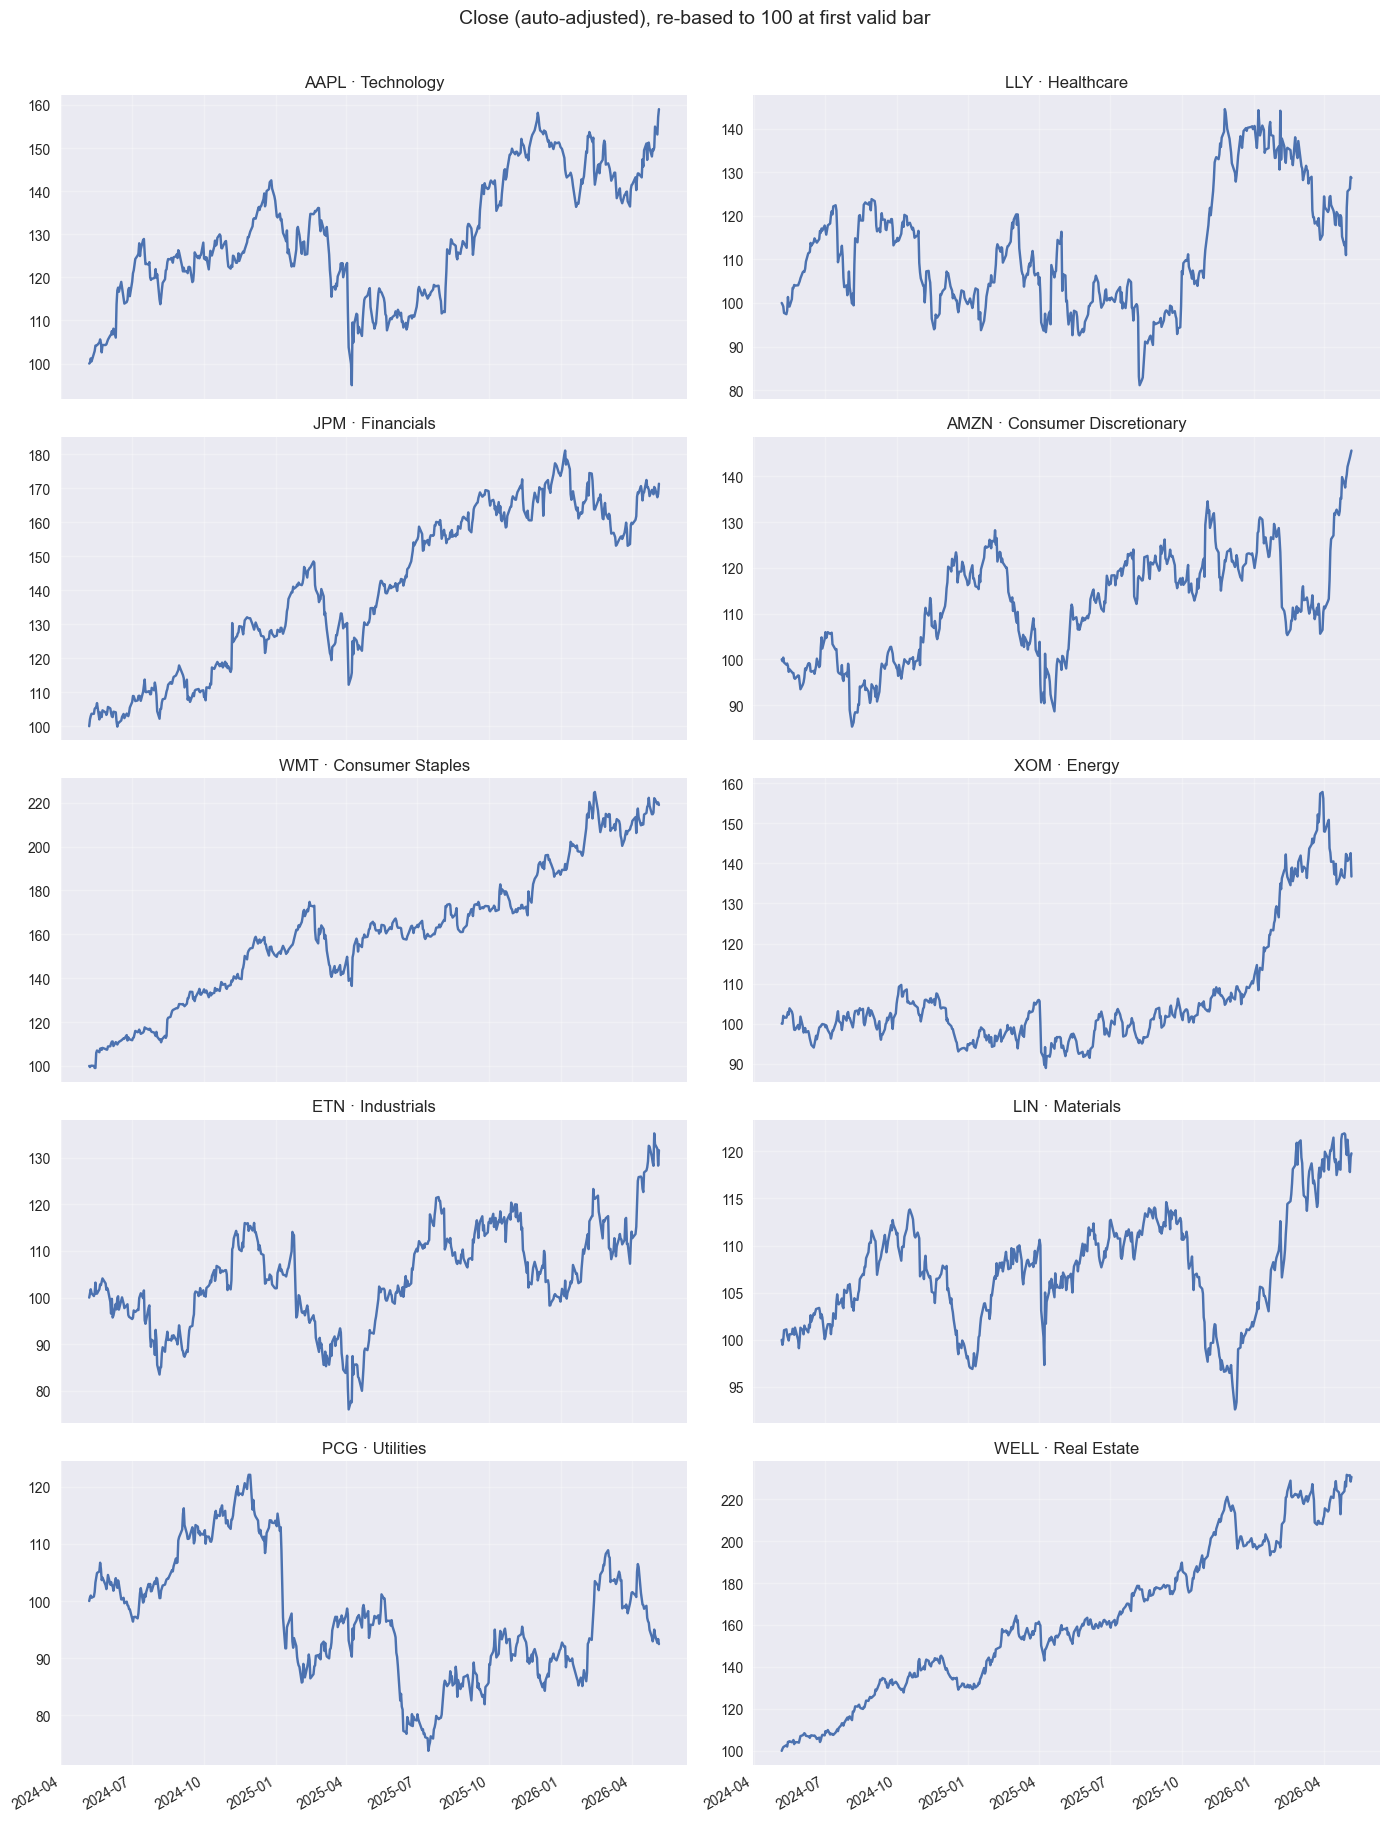

In [ ]:
# TODO: pick one representative ticker per sector (10 tickers total)
REP_TICKERS = ["AAPL", "LLY", "JPM", "AMZN", "WMT", "XOM", "ETN", "LIN", "PCG", "WELL"]

TICKER_TO_SECTOR = {t: sector for sector, tickers in SECTORS.items() for t in tickers}

close = raw_df["Close"]
fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
axes = axes.ravel()

for ax, stock in zip(axes, REP_TICKERS):
    s = close[stock]
    norm = s / s.iloc[0] * 100
    ax.plot(norm.index, norm.values)
    sector = TICKER_TO_SECTOR[stock]
    ax.set_title(f"{stock} · {sector}")
    ax.grid(True, alpha=0.3)

fig.suptitle("Close (auto-adjusted), re-based to 100 at first valid bar", fontsize=14, y=1.01)
fig.autofmt_xdate()
plt.tight_layout()

---
## 7. Persist to parquet

**Why parquet over CSV:**
- Preserves dtypes (DatetimeIndex stays a DatetimeIndex, no re-parsing)
- Significantly faster read for large DataFrames
- Smaller file size due to columnar compression

**What to save:** The cleaned `prices` DataFrame, plus a sector mapping so downstream notebooks know which ticker belongs to which sector.

In [ ]:
# TODO: save prices to DATA_DIR / 'prices.parquet'
DATA_DIR.mkdir(parents=True, exist_ok=True)

prices_path = DATA_DIR / "prices.parquet"
sector_path = DATA_DIR / "sector_map.parquet"

raw_df.to_parquet(prices_path)

# sector_map: Yahoo Finance sector per ticker (same labels as yfinance info["sector"] / GET /stock/{ticker})
def _yf_sector(sym: str) -> str:
    try:
        s = yf.Ticker(sym).info.get("sector")
        return s if isinstance(s, str) and s.strip() else "Unknown"
    except Exception:
        return "Unknown"


sector_df = pd.DataFrame(
    {"ticker": ALL_TICKERS, "sector": [_yf_sector(t) for t in ALL_TICKERS]}
)
sector_df.to_parquet(sector_path, index=False)

# For cells above that used TICKER_TO_SECTOR from the static dict (e.g. plots), refresh from Yahoo:
TICKER_TO_SECTOR = dict(zip(sector_df["ticker"], sector_df["sector"]))

# TODO: print file sizes for both — compare to what a CSV equivalent would be


def _kib(path: Path) -> float:
    return path.stat().st_size / 1024


print(raw_df.shape, f"| prices.parquet {_kib(prices_path):.1f} KiB")
print(sector_df.shape, f"| sector_map.parquet {_kib(sector_path):.1f} KiB")

csv_path = DATA_DIR / "_prices_size_probe.csv"
raw_df.to_csv(csv_path)
print(f"CSV sanity (same raw_df written then removed): {_kib(csv_path):.1f} KiB")
csv_path.unlink()

# TODO: reload from parquet and verify shape + dtypes match what you saved
raw_df_chk = pd.read_parquet(prices_path)
sector_chk = pd.read_parquet(sector_path)
assert raw_df_chk.shape == raw_df.shape
print("Reload OK shapes:", raw_df_chk.shape, sector_chk.shape)



(501, 750) | prices.parquet 3374.7 KiB
(150, 2) | sector_map.parquet 2.7 KiB
CSV sanity (same raw_df written then removed): 5934.7 KiB
Reload OK shapes: (501, 750) (150, 2)


---
## 8. Summary & handoff notes
```
Final universe size:         ___ tickers  (started with ~150)
Tickers dropped:             ___ (list them + reason)
Date range:                  ___ to ___
Trading days in dataset:     ___
Missing data after cleaning: ___ nulls remaining
Price column used:           Adj Close
Parquet output:              backend/data/prices.parquet, backend/data/sector_map.parquet
```